In [7]:
import os
os.environ.setdefault("BCD_DATA_FOLDER", "/data/gaetane")  # adapte si besoin

import torch
import matplotlib.pyplot as plt
import numpy as np

from dataloader import HiUCD_Dataset 
from encoder import DinoV2Encoder

In [3]:
ds_train = HiUCD_Dataset(cropsize=256, type="train", everything=True)

image1, image2, changemap, changemap2, landcover1, landcover2 = ds_train[9]

print("image1:", image1.shape, image1.dtype, image1.min().item(), image1.max().item())
print("image2:", image2.shape, image2.dtype, image2.min().item(), image2.max().item())
print("changemap:", changemap.shape, changemap.dtype, torch.unique(changemap))
print("landcover1:", landcover1.shape, landcover1.dtype, torch.unique(landcover1))
print("landcover2:", landcover2.shape, landcover2.dtype, torch.unique(landcover2))

image1: torch.Size([3, 256, 256]) torch.float32 0.054901961237192154 0.9607843160629272
image2: torch.Size([3, 256, 256]) torch.float32 0.0 1.0
changemap: torch.Size([256, 256]) torch.int32 tensor([0], dtype=torch.int32)
landcover1: torch.Size([256, 256]) torch.int64 tensor([0, 5, 8, 9])
landcover2: torch.Size([256, 256]) torch.int64 tensor([0, 5, 8, 9])


In [4]:
diff_mask = (landcover1 != landcover2).int()
changemap_np = changemap.squeeze().numpy()
diff_np = diff_mask.squeeze().numpy() if diff_mask.dim() > 2 else diff_mask.numpy()

agreement = (changemap_np == diff_np).mean()
print(f"Accord changemap vs (landcover1 != landcover2): {agreement:.3f}")
print("Proportion de pixels 'changé' dans changemap:", changemap_np.mean())
print("Proportion de pixels avec landcover1 != landcover2:", diff_np.mean())

Accord changemap vs (landcover1 != landcover2): 1.000
Proportion de pixels 'changé' dans changemap: 0.0
Proportion de pixels avec landcover1 != landcover2: 0.0


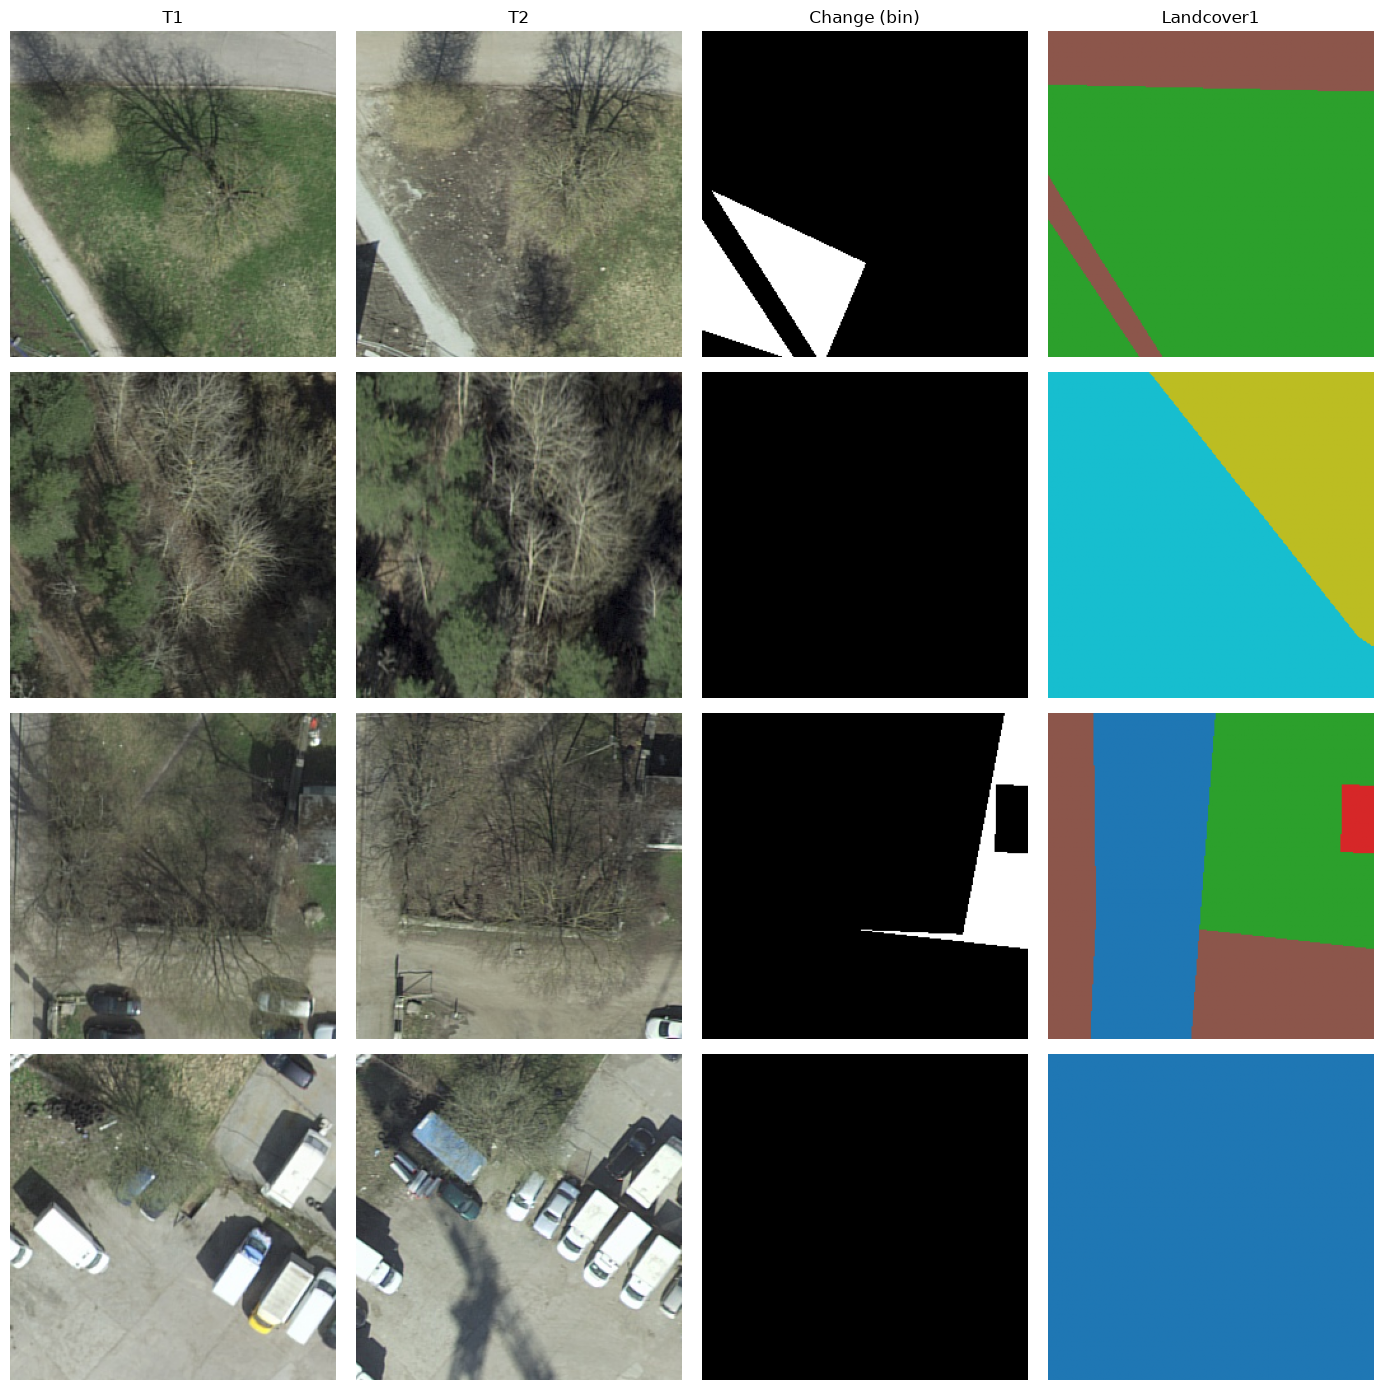

In [5]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_train, batch_size=4, shuffle=True)
image1, image2, changemap, _, landcover1, landcover2 = next(iter(loader))

fig, axs = plt.subplots(4, 4, figsize=(14, 14))
titles = ["T1", "T2", "Change (bin)", "Landcover1"]
for i in range(4):
    axs[i, 0].imshow(image1[i].permute(1, 2, 0))
    axs[i, 1].imshow(image2[i].permute(1, 2, 0))
    axs[i, 2].imshow(changemap[i], cmap="gray", vmin=0, vmax=1)
    axs[i, 3].imshow(landcover1[i], cmap="tab10", vmin=0, vmax=9)
    for j in range(4):
        axs[i, j].axis("off")
        if i == 0:
            axs[i, j].set_title(titles[j])
plt.tight_layout()
plt.show()


## Vérification encodeur 


In [8]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch = im1.unsqueeze(0)

with torch.no_grad():
    x = encoder(im1_batch)

print("x shape:", x.shape)
print("out_channels attendu:", encoder.out_channels)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /home/gaetane/.cache/torch/hub/main.zip


/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /home/gaetane/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100.0%


x shape: torch.Size([1, 384, 16, 16])
out_channels attendu: 384
